# Compressed Sensing and Basis Pursuit

Recover sparse $x^\star$ from underdetermined measurements $y=Ax^\star$ by solving
$$
\min_x \|x\|_1 \quad \text{s.t.}\quad Ax=y
$$
or its penalized version (LASSO):
$$
\min_x \tfrac12\|Ax-y\|_2^2+\lambda\|x\|_1.
$$


## Environment

We load numerical tools and define a notebook-local output directory for generated figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/compressed-sensing-basis-pursuit") if Path("python/compressed-sensing-basis-pursuit").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Numerical Experiment

We implement the core algorithm and generate comparative visuals to expose behavior clearly.


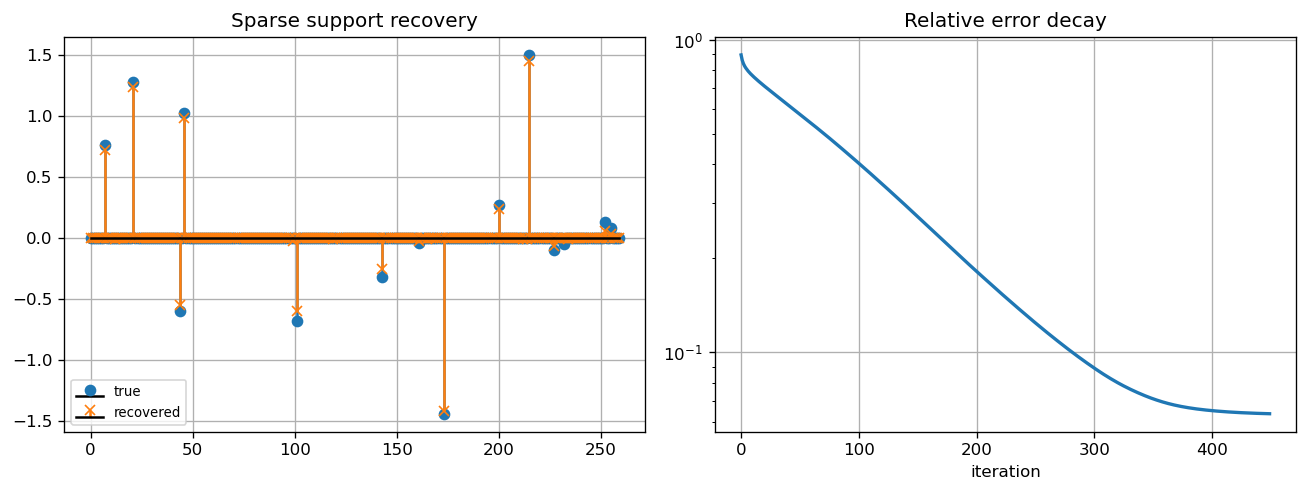

In [2]:
rng = np.random.default_rng(0)
m, n = 90, 260
s = 14
A = rng.standard_normal((m, n))/np.sqrt(m)
x_true = np.zeros(n)
idx = rng.choice(n, size=s, replace=False)
x_true[idx] = rng.standard_normal(s)
y = A @ x_true

lam = 0.03
L = np.linalg.norm(A, 2)**2
tau = 1.0/L

def soft(z, t):
    return np.sign(z)*np.maximum(np.abs(z)-t, 0.0)

x = np.zeros(n)
errs = []
for _ in range(450):
    x = soft(x - tau*(A.T@(A@x - y)), lam*tau)
    errs.append(np.linalg.norm(x-x_true)/np.linalg.norm(x_true))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].stem(x_true, linefmt="C0-", markerfmt="C0o", basefmt="k-", label="true")
axes[0].stem(x, linefmt="C1-", markerfmt="C1x", basefmt="k-", label="recovered")
axes[0].set_title("Sparse support recovery"); axes[0].legend(fontsize=8)
axes[1].plot(errs, lw=2); axes[1].set_yscale("log")
axes[1].set_title("Relative error decay"); axes[1].set_xlabel("iteration")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- D. L. Donoho, "Compressed Sensing", IEEE TIT, 2006.
- E. J. Candès, J. Romberg, T. Tao, "Robust Uncertainty Principles", IEEE TIT, 2006.
- S. Boyd et al., "Distributed Optimization and Statistical Learning via ADMM", Foundations and Trends in ML, 2011.
